In [79]:
import numpy as np
from embedding_class import synthetic_data_generation, observation_map,embedding, MLE
import statsmodels.api as sm
from scipy.linalg import orthogonal_procrustes
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from scipy.linalg import solve_discrete_are

# 1. Phase 4: Kalman Filter Coupling and Nyström Lifting
### Kalman filter class

In [80]:
import numpy as np

class LinearKalmanFilter:
    def __init__(self, A, Q, H, R, Z0=None, P0=None):
        self.A = np.asarray(A)
        self.Q = np.asarray(Q)
        self.H = np.asarray(H)
        self.R = np.asarray(R)

        self.k = self.A.shape[0]

        if Z0 is None:
            Z0 = np.zeros(self.k)

        if P0 is None:
            P0 = np.eye(self.k)

        self.Ztm1_tm1 = np.asarray(Z0)
        self.Ptm1_tm1 = np.asarray(P0)

    def predict(self):
        self.Zt_tm1 = self.A @ self.Ztm1_tm1
        self.Pt_tm1 = self.A @ self.Ptm1_tm1 @ self.A.T + self.Q

        return self.Zt_tm1, self.Pt_tm1

    def update(self, z):
        z = np.asarray(z)

        S = self.H @ self.Pt_tm1 @ self.H.T + self.R
        K = self.Pt_tm1 @ self.H.T @ np.linalg.inv(S)
        self.Kt = K

        innovation = z - self.H @ self.Zt_tm1

        self.Zt_t = self.Zt_tm1 + K @ innovation
        self.Pt_t = (np.eye(self.k) - K @ self.H) @ self.Pt_tm1

        return self.Zt_t, self.Pt_t

    def one_step(self, z):
        self.predict()
        self.update(z)
        self.Ztm1_tm1 = self.Zt_t
        self.Ptm1_tm1 = self.Pt_t
        return self.Zt_t, self.Pt_t

    def run(self, Zobs):
        self.Zobs = np.asarray(Zobs)
        self.N = Zobs.shape[0]

        self.predicted = np.zeros((self.N, self.k))
        self.filtered = np.zeros((self.N, self.k))
        self.covariates = np.zeros((self.N, self.k, self.k))

        for i in range(self.N):
            
            Z_filt, P_filt = self.one_step(Zobs[i])
            self.predicted[i] = self.Zt_tm1
            self.filtered[i] = Z_filt
            self.covariates[i] = P_filt

        return self.filtered, self.predicted, self.covariates
    
    def ljung_box_test(self):
        inov = self.Zobs - self.predicted @ self.H.T
        df1 = sm.stats.acorr_ljungbox(inov[10:, 0], lags=6, return_df=True)
        df2 = sm.stats.acorr_ljungbox(inov[10:, 1], lags=6, return_df=True)

        df = pd.concat([df1, df2], axis=1)
        df.columns = ["lb_stat_1", "lb_pvalue_1", "lb_stat_2", "lb_pvalue_2"]

        return df      
    
    def riccati_convergence(self):

        if not hasattr(self, 'covariates'):
            raise AttributeError("Build covariates first by running run() first.")
        
        P_inf_prior = solve_discrete_are(
            self.A.T,
            self.H.T,
            self.Q,
            self.R
        )

        S_inf = self.H @ P_inf_prior @ self.H.T + self.R
        K_inf = P_inf_prior @ self.H.T @ np.linalg.inv(S_inf)
        P_inf_post = (np.eye(self.k) - K_inf @ self.H) @ P_inf_prior


        err = np.array([
            np.linalg.norm(self.covariates[t] - P_inf_post, ord="fro")
            for t in range(len(self.covariates))
        ])

        return err
        

### Kalman filter class usage

In [81]:
LATENT_SEED, FEATURE_SEED, NOISE_SEED = 0, 1, 2
SIGMA_ETAS, DS = [0.0, 0.05, 0.1, 0.2], [50, 100]

# Get latent state on sphere
latent = synthetic_data_generation(rand_seed=LATENT_SEED)
latent.thin_trajectories(gap=10, burnin=500)

kappa = latent.kappa
sigma = latent.sigma
dt = latent.dt
T = latent.T
dt_eff = latent.dt_eff
gap = latent.gap

# Generate observations
obs = observation_map(latent.X_geom, D=100, feature_seed=FEATURE_SEED)
clean = obs.clean_state()
Zobs = obs.sample_observation(0.05)

# Get embedding
dm = embedding()
w, Psi_noisy = dm.get_embedding(Zobs, alpha=1, k=4)

# Embedding for g(Xt) without noise
w_clean, Psi_clean = dm.get_embedding(clean["Gclean"])

mle = MLE()
kappa_hat, sigma_hat, _, _ = mle.ou_mle(Psi_noisy[:, :2], dt_eff)


In [82]:
kappa_hat, sigma_hat

kappa_hat = kappa
sigma_hat = sigma

In [83]:
def align_embedding(Y, Psi):
    """
    Align diffusion coordinates Psi to latent coordinates Y
    using orthogonal Procrustes alignment.

    Returns:
        Y_c: centred latent coordinates
        Psi_align: centred and aligned embedding
        R: orthogonal transformation
    """

    # centre both clouds
    Y_c = Y - Y.mean(axis=0)
    Psi_c = Psi - Psi.mean(axis=0)
    # best orthogonal map Psi_c @ R ≈ Y_c
    R, _ = orthogonal_procrustes(Psi_c, Y_c)
    # aligned embedding
    Psi_align = Psi_c @ R

    return Y_c, Psi_align, R

Psi_clean_c, Psi_noisy_align, R = align_embedding(Psi_clean[:, 2:], Psi_noisy[:, 2:])

In [84]:
k = 2
dt_eff = gap * dt

a = np.exp(-kappa_hat * dt_eff)

A = a * np.eye(k)

Q = (sigma_hat**2 / (2*kappa_hat)) * (1 - np.exp(-2*kappa_hat*dt_eff)) * np.eye(k)

H = np.eye(k)

R = np.cov((Psi_noisy_align - Psi_clean_c).T)

P0 = sigma_hat**2 / (2*kappa_hat) * np.eye(k)

Z0 = np.zeros(k)

kf = LinearKalmanFilter(A, Q, H, R, Z0=Z0, P0=P0)

filtered, predicted, covariates = kf.run(Psi_noisy[:, :k])

In [7]:
kf.ljung_box_test()

,lb_stat_1,lb_pvalue_1,lb_stat_2,lb_pvalue_2
1,219.084475,1.432468e-49,209.833961,1.493107e-47
2,253.674540,8.227606e-56,225.494387,1.082720e-49
3,256.037468,3.235553e-55,226.268271,8.863963e-49
4,256.038553,3.255286e-54,226.354527,8.041160e-48
5,257.503901,1.348288e-53,226.354615,6.463470e-47
6,259.882157,3.165584e-53,226.986148,3.366246e-46


In [78]:
Zobs.shape

(946, 100)

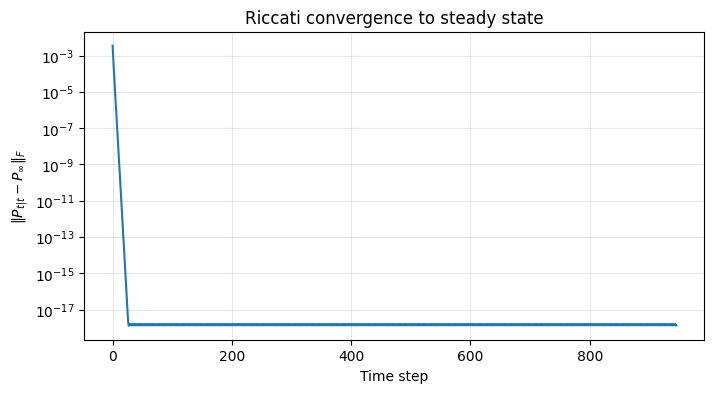

In [88]:
kf = LinearKalmanFilter(A, Q, H, R, Z0, P0)
filtered, predicted, covariates = kf.run(Psi_noisy[:, :2])
err = kf.riccati_convergence()


plt.figure(figsize=(8, 4))
plt.semilogy(err)
plt.xlabel("Time step")
plt.ylabel(r"$\|P_{t|t} - P_\infty\|_F$")
plt.title("Riccati convergence to steady state")
plt.grid(True, alpha=0.3)
plt.show()

# 1.2. Task 4.2: Nyström extension for out-of-sample lifting

Store the training point cloud, the kernel bandwidth ε
⋆
, the empirical degrees {qi}, and
the eigenpairs {(λℓ
, ϕℓ)} from the Phase 2 diffusion map

In [93]:
# Get latent state on sphere
latent = synthetic_data_generation(rand_seed=LATENT_SEED)
latent.thin_trajectories(gap=10, burnin=500)

X_geom = latent.X_geom

kappa = latent.kappa
sigma = latent.sigma
dt = latent.dt
T = latent.T
dt_eff = latent.dt_eff
gap = latent.gap

# Generate observations
obs = observation_map(latent.X_geom, D=100, feature_seed=FEATURE_SEED)
clean = obs.clean_state()
Zobs = obs.sample_observation(0.05)

# Get embedding
dm = embedding()
w, Psi_noisy = dm.get_embedding(Zobs, alpha=1, k=4)
q = dm.q
eps = dm.eps; 
w, v = dm.w, dm.v

store = {"Psi": Psi_noisy[:, :2], "Zobs": Zobs, "X": X_geom, "eps": eps, "q": q, "w": w, "v": v}

In [ ]:
def oos_lifting(y_new, store):

    k = store["Psi"].shape[1]

    w_new = np.exp(-np.linalg.norm(y_new - store["Zobs"], axis=1)**2 / store["eps"])
    q_new = np.sum(w_new)

    w_a_new = w_new / (q_new * store["q"])

    w_a_t_new = w_a_new / np.sum(w_a_new)

    Psi_l = 1/store["w"][:k] * (w_a_t_new.T @ store["Psi"])

    return store["w"][:k] * Psi_l


array([0.0855351 , 0.00294129])

In [95]:
# Generate observations
obs = observation_map(latent.X_test, D=100, feature_seed=FEATURE_SEED)
y_new = obs.sample_observation(0.05)

store["X"].shape

(946, 3)

### Testing of out-of-sample lifting
Idempotence

In [116]:
Zobs = store["Zobs"]
Psi = store["Psi"]
N = Zobs.shape[0]
errors = np.zeros((N, 2))

for i in range(N):

    true_z = Zobs[i, :]
    true = Psi[i, :]

    reembedded = oos_lifting(true_z, store)
    errors[i] = reembedded - true

np.mean(errors, axis=0)

array([-5.57866486e-05, -9.28978790e-05])

Continuity

In [ ]:
Zobs = store["Zobs"]
Psi = store["Psi"]

deltas = np.linspace(1e-3, 1)

eg = Zobs[0, :]
eg_Psi = Psi[0, :]

for delta in deltas:
    

array([0.01428249, 0.02000644])